In [1]:
import tensorflow as tf
import numpy as np
import pandas as pd
from pylab import rcParams
import matplotlib.pyplot as plt
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import seaborn as sns
warnings.filterwarnings("ignore")

In [2]:
x , y = make_circles(n_samples = 100 , noise = 0.1 , random_state = 1)

<Axes: >

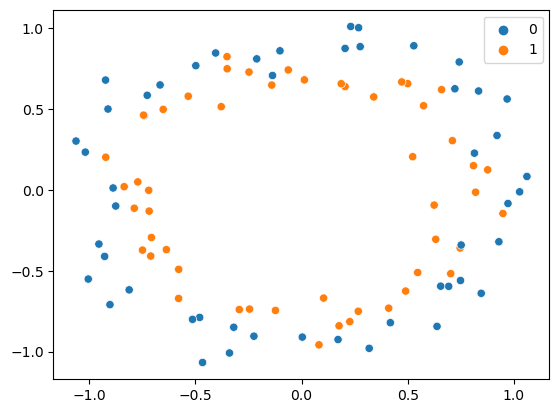

In [3]:
sns.scatterplot(x=x[:,0], y=x[:,1], hue=y)

In [4]:
x_train , x_test , y_train ,y_test = train_test_split(x,y , test_size = .2 , random_state = 42)

In [5]:
model  = Sequential()

model.add(Dense(256,activation = "relu" , input_dim=2))
model.add(Dense(1 , activation = "sigmoid"))

In [6]:
model.compile(loss = "binary_crossentropy" , optimizer = "adam" ,metrics = ['accuracy'])

In [7]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               768       
                                                                 
 dense_1 (Dense)             (None, 1)                 257       
                                                                 
Total params: 1025 (4.00 KB)
Trainable params: 1025 (4.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [8]:
history = model.fit(x_train , y_train , validation_data=(x_test , y_test) , epochs = 1000,batch_size = 20)

Epoch 1/1000


4/4 [==============================] - 1s 64ms/step - loss: 0.6949 - accuracy: 0.4750 - val_loss: 0.6987 - val_accuracy: 0.4500
Epoch 2/1000
4/4 [==============================] - 0s 12ms/step - loss: 0.6906 - accuracy: 0.5000 - val_loss: 0.7030 - val_accuracy: 0.4500
Epoch 3/1000
4/4 [==============================] - 0s 14ms/step - loss: 0.6885 - accuracy: 0.4750 - val_loss: 0.7083 - val_accuracy: 0.3500
Epoch 4/1000
4/4 [==============================] - 0s 14ms/step - loss: 0.6855 - accuracy: 0.5375 - val_loss: 0.7131 - val_accuracy: 0.3500
Epoch 5/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.6844 - accuracy: 0.5375 - val_loss: 0.7190 - val_accuracy: 0.3500
Epoch 6/1000
4/4 [==============================] - 0s 9ms/step - loss: 0.6823 - accuracy: 0.5375 - val_loss: 0.7231 - val_accuracy: 0.3500
Epoch 7/1000
4/4 [==============================] - 0s 11ms/step - loss: 0.6809 - accuracy: 0.5375 - val_loss: 0.7260 - val_accuracy: 0.3500
Epoch 8/1000

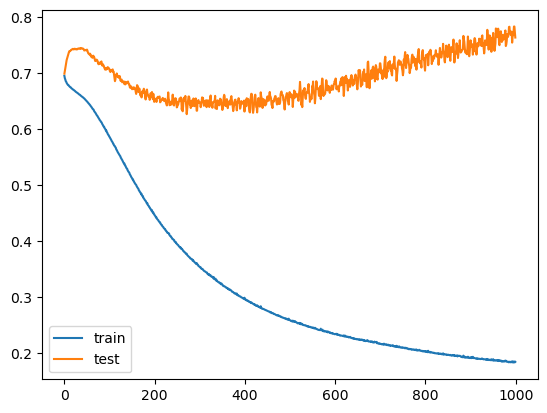

In [9]:
plt.plot(history.history["loss"] , label = "train")
plt.plot(history.history["val_loss"] , label = "test")
plt.legend()

9600/9600 [==============================] - 10s 1ms/step


<Axes: >

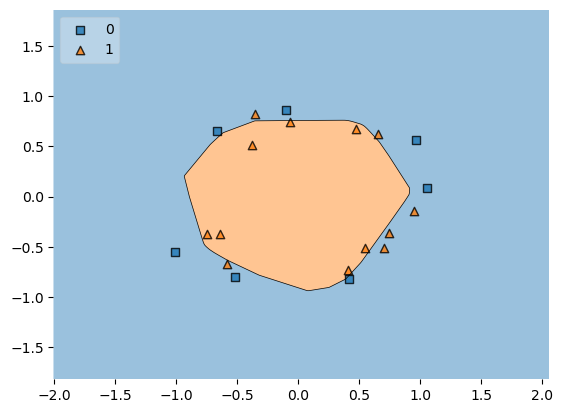

In [10]:
plot_decision_regions(x_test , y_test.ravel() ,clf = model , legend = 2)

In [ ]:
# early stopping

In [11]:
model1 = Sequential()
model1.add(Dense(256 , activation = "relu" , input_dim = 2))
model1.add(Dense(1,activation = "sigmoid"))

In [12]:
callback = EarlyStopping(monitor = "val_loss" , min_delta = .00001 , patience = 20 , mode = "auto" , baseline = None , restore_best_weights = False,verbose = 1)

In [13]:
model1.compile(loss = "binary_crossentropy" , optimizer = "adam" , metrics=["accuracy"])

In [14]:
model1.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_2 (Dense)             (None, 256)               768       
                                                                 
 dense_3 (Dense)             (None, 1)                 257       
                                                                 
Total params: 1025 (4.00 KB)
Trainable params: 1025 (4.00 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [18]:
history1 = model1.fit(x_train , y_train , validation_data=(x_test , y_test) , epochs=50000000 ,batch_size=20, callbacks=callback)

Epoch 1/50000000
4/4 [==============================] - 0s 24ms/step - loss: 0.3773 - accuracy: 0.8875 - val_loss: 0.6378 - val_accuracy: 0.7000
Epoch 2/50000000
4/4 [==============================] - 0s 14ms/step - loss: 0.3760 - accuracy: 0.8750 - val_loss: 0.6388 - val_accuracy: 0.7000
Epoch 3/50000000
4/4 [==============================] - 0s 15ms/step - loss: 0.3750 - accuracy: 0.8750 - val_loss: 0.6396 - val_accuracy: 0.7000
Epoch 4/50000000
4/4 [==============================] - 0s 9ms/step - loss: 0.3752 - accuracy: 0.8750 - val_loss: 0.6465 - val_accuracy: 0.6500
Epoch 5/50000000
4/4 [==============================] - 0s 11ms/step - loss: 0.3735 - accuracy: 0.8750 - val_loss: 0.6371 - val_accuracy: 0.7000
Epoch 6/50000000
4/4 [==============================] - 0s 11ms/step - loss: 0.3732 - accuracy: 0.8875 - val_loss: 0.6319 - val_accuracy: 0.7000
Epoch 7/50000000
4/4 [==============================] - 0s 12ms/step - loss: 0.3727 - accuracy: 0.8875 - val_loss: 0.6312 - val_acc

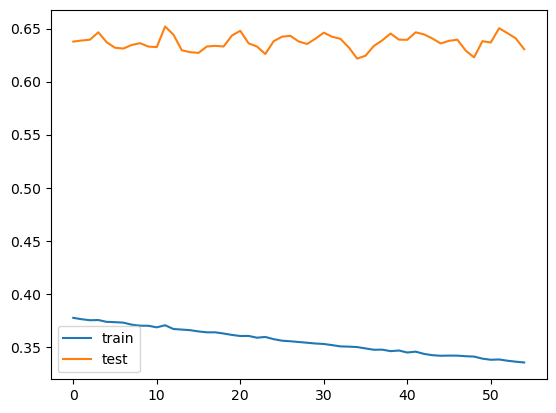

In [19]:
plt.plot(history1.history["loss"] , label = "train")
plt.plot(history1.history["val_loss"] , label = "test")
plt.legend()